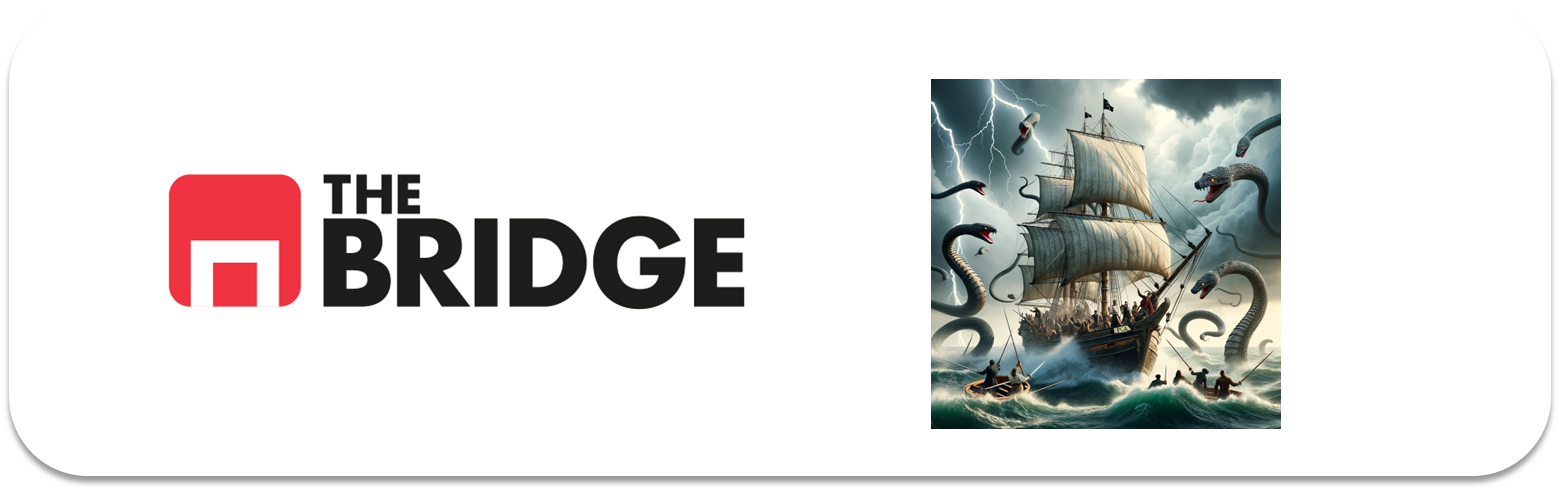

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Core
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import bootcampviztools as bt

# Sklearn: split, metrics, preprocessing, pipelines
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Selección de Feature
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, SelectFromModel, RFE, SequentialFeatureSelector)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# PCA
from sklearn.decomposition import PCA

# Utils
import warnings
warnings.filterwarnings("ignore")


In [1]:
import sys
print(sys.executable)

c:\Users\helad\OneDrive\Escritorio\DataScience\venv\Scripts\python.exe


In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
df.shape

(12537, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [5]:
def data_report(df):
    '''Esta funcion describe los campos de un dataframe de pandas de forma bastante clara, crack'''
    # Sacamos los NOMBRES
    cols = pd.DataFrame(df.columns.values, columns=["COL_N"])

    # Sacamos los TIPOS
    types = pd.DataFrame(df.dtypes.values, columns=["DATA_TYPE"])

    # Sacamos los MISSINGS
    percent_missing = round(df.isnull().sum() * 100 / len(df), 2)
    percent_missing_df = pd.DataFrame(percent_missing.values, columns=["MISSINGS (%)"])

    # Sacamos los VALORES UNICOS
    unicos = pd.DataFrame(df.nunique().values, columns=["UNIQUE_VALUES"])
    
    percent_cardin = round(unicos['UNIQUE_VALUES']*100/len(df), 2)
    percent_cardin_df = pd.DataFrame(percent_cardin.values, columns=["CARDIN (%)"])

    concatenado = pd.concat([cols, types, percent_missing_df, unicos, percent_cardin_df], axis=1, sort=False)
    concatenado.set_index('COL_N', drop=True, inplace=True)

    return concatenado.T

In [6]:
data_report(df)

COL_N,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
DATA_TYPE,int64,float64,int64,int64,float64,float64,int64,int64,int64,int64,float64
MISSINGS (%),0.0,0.0,0.0,0.0,0.0,5.75,0.0,0.0,0.0,0.0,1.41
UNIQUE_VALUES,2,10764,78,10,11547,4167,43,13,16,8,10
CARDIN (%),0.02,85.86,0.62,0.08,92.1,33.24,0.34,0.1,0.13,0.06,0.08


In [7]:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


In [8]:
df["NumberOfOpenCreditLinesAndLoans"].value_counts()

NumberOfOpenCreditLinesAndLoans
7     1148
6     1087
8     1037
5     1035
9      977
4      935
10     782
11     732
3      722
12     580
2      547
13     459
1      416
14     368
15     341
16     239
17     217
0      192
18     153
19     129
20     118
21      62
22      61
23      39
24      38
25      30
26      19
27      16
28      13
29      10
30      10
31       7
33       4
32       3
34       2
35       2
36       1
38       1
43       1
48       1
49       1
41       1
40       1
Name: count, dtype: int64

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

In [9]:
# nos deshacemos de los nulos

df = df.dropna()

In [10]:
df.shape

(11816, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

In [12]:
# Hago un pequeño bucle para verme todos los value_counts los valores unicos y el % de 0 para ver cuales vale la pena categorizar
# el % de ceros lo que me va a indicar, si es alto, es que la mayoría es 0 veces y luego algunas 1-2-3 etc, por lo que serían
# las mejores para hacer de niveles (1-3)

columnas_numberof = [col for col in df.columns if col.startswith("NumberOf")]

for col in columnas_numberof:
    distribucion_porcentaje = (df[col].value_counts(normalize= True, dropna= False).sort_index())
    
    porcentaje_ceros = distribucion_porcentaje.get(0, 0)

    print(f"\n{col} | valores_unicos =  {df[col].nunique()} | porcentaje_0 = {porcentaje_ceros:.2%}")
    print((distribucion_porcentaje.head(10) * 100).round(2))



NumberOfTime30-59DaysPastDueNotWorse | valores_unicos =  10 | porcentaje_0 = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0     83.09
1     11.46
2      3.36
3      1.07
4      0.54
5      0.19
6      0.17
7      0.01
8      0.02
98     0.08
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores_unicos =  43 | porcentaje_0 = 0.95%
NumberOfOpenCreditLinesAndLoans
0    0.95
1    2.60
2    3.77
3    5.40
4    7.18
5    8.15
6    8.73
7    9.39
8    8.54
9    8.17
Name: proportion, dtype: float64

NumberOfTimes90DaysLate | valores_unicos =  13 | porcentaje_0 = 94.41%
NumberOfTimes90DaysLate
0    94.41
1     3.33
2     1.20
3     0.46
4     0.26
5     0.12
6     0.05
7     0.03
8     0.03
9     0.01
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores_unicos =  8 | porcentaje_0 = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0     94.84
1      4.05
2      0.72
3      0.15
4      0.12
5      0.03
11     0.01
98     0.08
Name: proportion, dtype: 

### Binning `NumberOf...` (2–3 niveles)

Revisé `value_counts(normalize=True)` y las variables de mora están muy concentradas en 0 (90DaysLate 94.41%, 60-89 94.84%, 30-59 83.09%). Para simplificar y cumplir el enunciado, convierto:
- `NumberOfTimes90DaysLate` y `NumberOfTime60-89DaysPastDueNotWorse` → **2 niveles**: `0` vs `1+`
- `NumberOfTime30-59DaysPastDueNotWorse` → **3 niveles**: `0` / `1-2` / `3+`

Mantengo numéricas `NumberOfOpenCreditLinesAndLoans` y `NumberOfDependents` por tener distribución más repartida.


In [ ]:
# Columnas a binnear

col_30_59 = "NumberOfTime30-59DaysPastDueNotWorse"
col_60_89 = "NumberOfTime60-89DaysPastDueNotWorse"
col_90    = "NumberOfTimes90DaysLate"

# 2 niveles: 0vs1+ -> codifico como 0/1

df[col_90] = (df[col_90] != 0).astype(int).astype("category")
df[col_60_89] = (df[col_60_89] != 0).astype(int).astype("category")

# 3 niveles: 0/1-2/3+ -> codifico como 0/1/2

df[col_30_59] = pd.cut(df[col_30_59], bins=[-0.5, 0.5, 2.5, np.inf], labels=[0, 1, 2]).astype("category")

# Chequeo rápido

df[[col_30_59, col_60_89, col_90]].head()


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
0,0,0,1
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [14]:
df[[col_30_59, col_60_89, col_90]].dtypes

NumberOfTime30-59DaysPastDueNotWorse    category
NumberOfTime60-89DaysPastDueNotWorse    category
NumberOfTimes90DaysLate                 category
dtype: object

In [15]:
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [16]:
X = df.drop("SeriousDlqin2yrs", axis= 1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify= y, test_size= 0.2, random_state= 42)

In [21]:
X_train.shape

(9452, 10)

In [22]:
y_train.shape

(9452,)

In [ ]:
y.value_counts(normalize= True)

SeriousDlqin2yrs
0    0.929756
1    0.070244
Name: proportion, dtype: float64

In [ ]:
y_train.value_counts(normalize= True)

SeriousDlqin2yrs
0    0.92975
1    0.07025
Name: proportion, dtype: float64

In [ ]:
y_test.value_counts(normalize= True)

SeriousDlqin2yrs
0    0.92978
1    0.07022
Name: proportion, dtype: float64

Por desbalance 93/7, accuracy no es informativa, usaré balanced accuracy / recall macro

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).



In [24]:
features_num = X_train.select_dtypes(include=["number"]).columns
features_cat = X_train.select_dtypes(include=["category"]).columns

In [26]:
features_num

Index(['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
       'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents'],
      dtype='object')

In [27]:
features_cat

Index(['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'NumberOfTime60-89DaysPastDueNotWorse'],
      dtype='object')

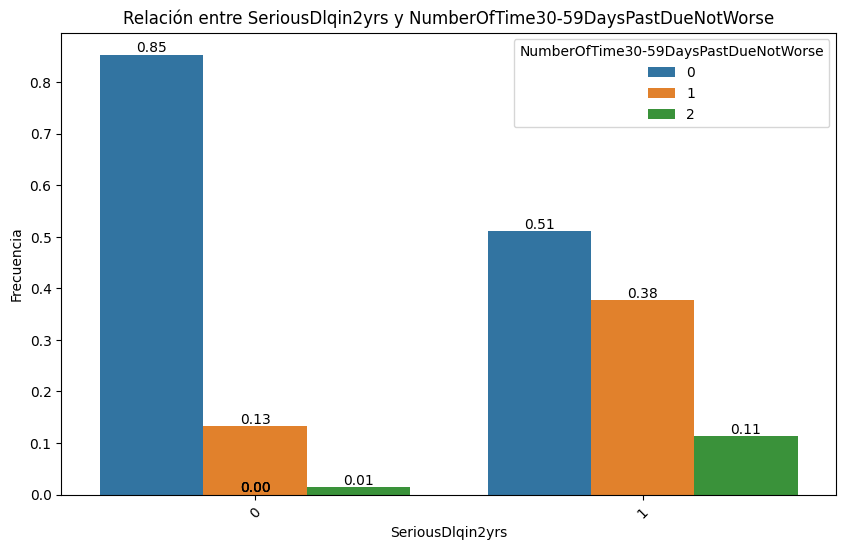

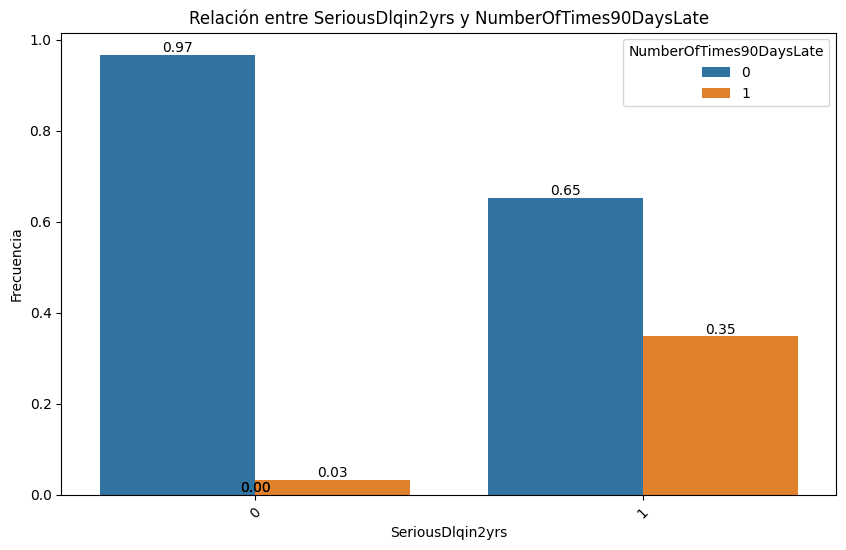

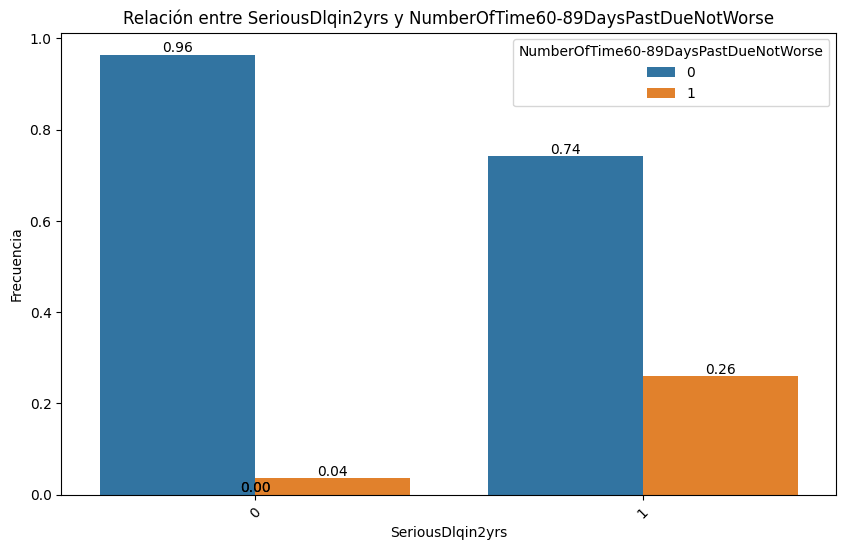

In [25]:
df_train = pd.concat([X_train, y_train], axis=1)
target = "SeriousDlqin2yrs"

for cat_col in features_cat:
    bt.plot_categorical_relationship_fin(df_train, target, cat_col, show_values= True, relative_freq= True)

En `NumberOfTime30-59DaysPastDueNotWorse` se observa una clara separación por clase: entre los `SeriousDlqin2yrs=0` predomina el nivel 0 (~85%)   

Mientras que en `SeriousDlqin2yrs=1` baja el nivel 0 (~51%) y aumentan los niveles 1 (~38%) y 2 (~11%).  

Esto sugiere que más episodios de retraso 30–59 días están asociados a mayor probabilidad de impago.


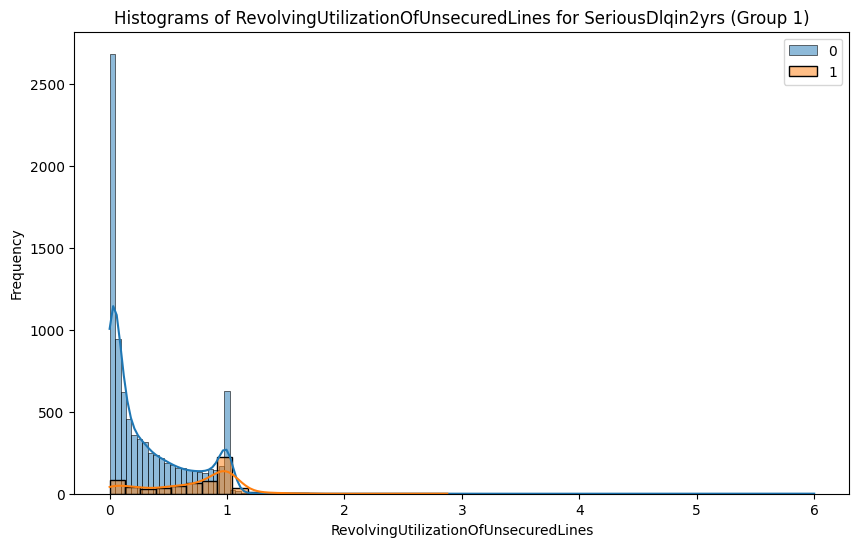

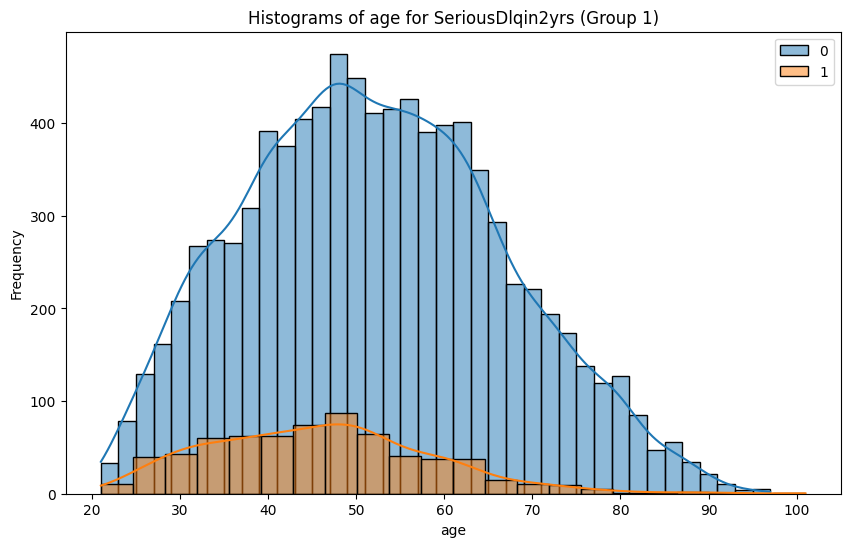

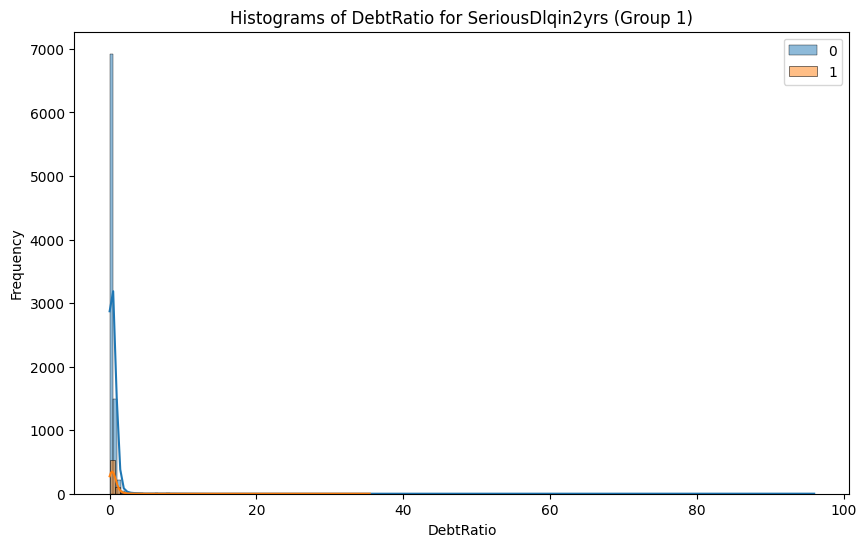

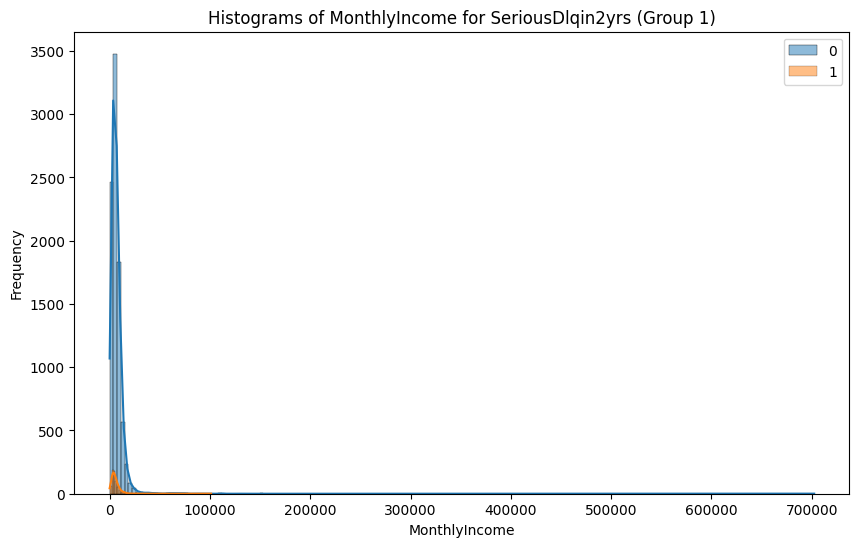

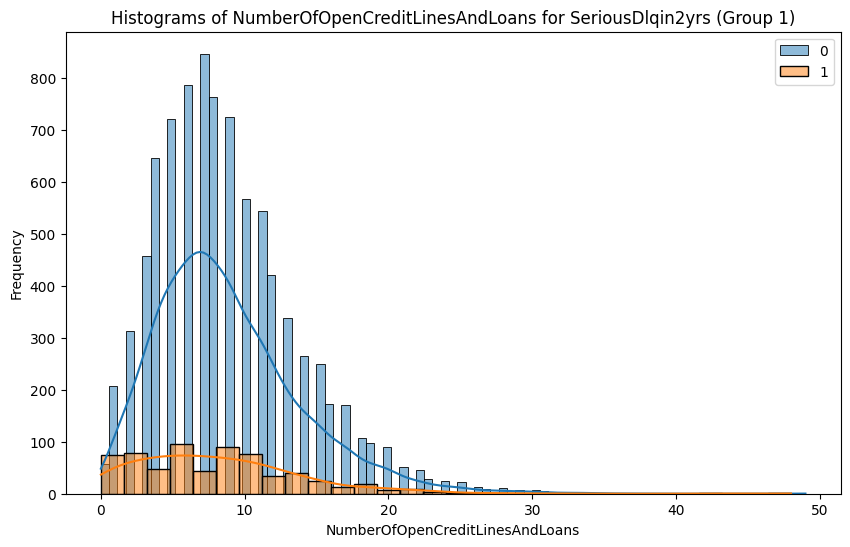

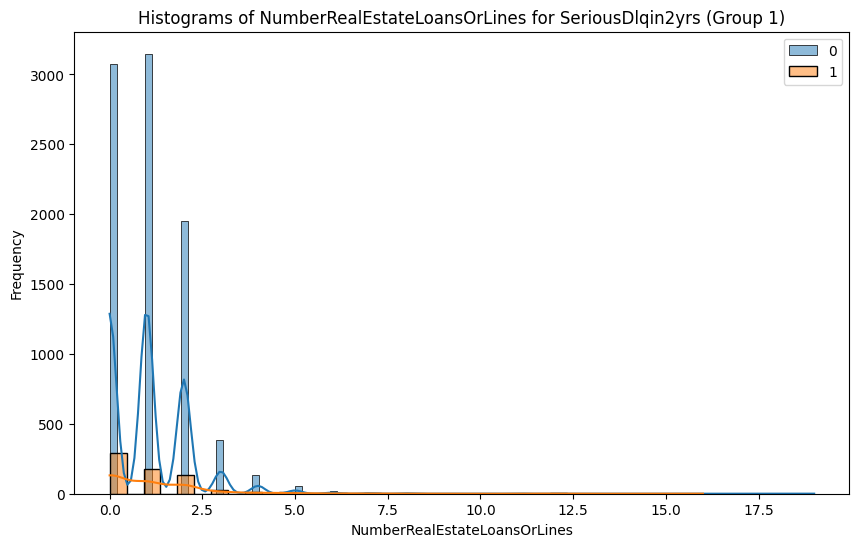

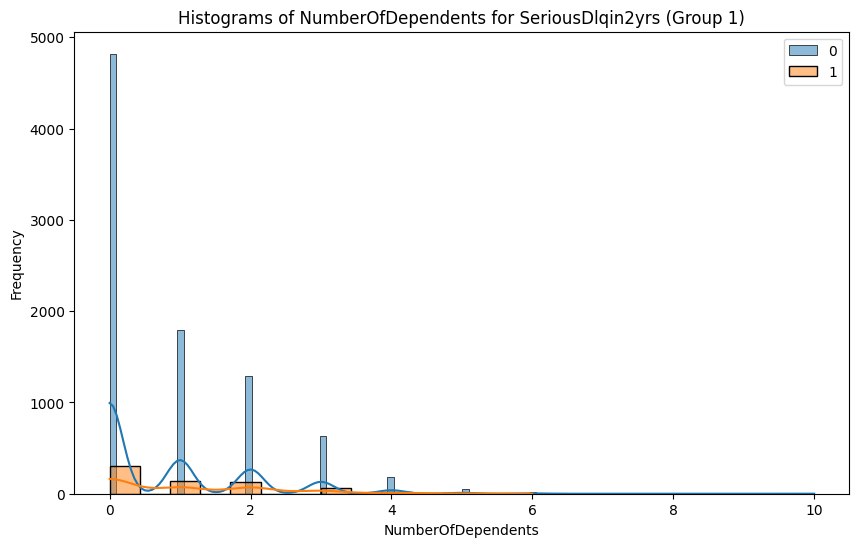

In [29]:
for num_col in features_num:
    bt.plot_grouped_histograms(df_train, cat_col= target, num_col= num_col, group_size=2)

In [31]:
corr = X_train[features_num].corr()
serie_corr = X_train[features_num].corrwith(y_train).abs()
serie_corr.sort_values(ascending = False)

RevolvingUtilizationOfUnsecuredLines    0.277475
age                                     0.105251
NumberOfDependents                      0.046099
NumberOfOpenCreditLinesAndLoans         0.033514
MonthlyIncome                           0.025449
NumberRealEstateLoansOrLines            0.005770
DebtRatio                               0.000089
dtype: float64

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.



4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.